In [17]:
#Imports loaded
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
#coffea output file
f_bkg = "../coffea/skimmed/HT_skimmed_WJets_2022.coffea"

#Nested Dictionary:
bkg_histo = util.load(f_bkg) [0]
c_eff = util.load(f_bkg) [0]['cutflow']['bkg_2022_WJets_WJetsToLNu4']
print(c_eff)


defaultdict(<class 'float'>, {'all': 0.024379769422406036, 'hasVtx': 0.003603885407486982, 'cut1': 0.003603885407486982, 'cut2': 0.003603885407486982, 'cut3': 0.003603885407486982, 'cut4': 0.003603885407486982, 'cut5': 0.003603885407486982, 'cut6': 0.0035900006944076203, 'cut7': 0.003469340663408249, 'cut8': 0.0033629216113175145, 'cut9': 0.0021510994049834618, 'cut10': 8.397195934625777e-05})


In [19]:
cutNames = {cname:ptools.getCut(bkg_histo['cutDesc'][cname]) for cname in bkg_histo['cutDesc'].keys()}
print(cutNames)

cuts=cutNames.keys()
print("cuts:",cuts)
desc=list(cutNames.values())
print(desc)

{'all': 'No cuts', 'hasVtx': 'Baseline Selection', 'cut1': 'Pass MET Filters', 'cut2': 'HEM Veto', 'cut3': 'MET Trigger (120 GeV)', 'cut4': 'MET > 200 GeV', 'cut5': 'No b-tagged jets', 'cut6': 'Leading jet pT > 80 GeV', 'cut7': 'Leading jet |eta| < 2.4', 'cut8': 'dPhi(MET,leading jet) > 2.0', 'cut9': 'dPhi(MET,all jets) > 0.75', 'cut10': 'BDT'}
cuts: dict_keys(['all', 'hasVtx', 'cut1', 'cut2', 'cut3', 'cut4', 'cut5', 'cut6', 'cut7', 'cut8', 'cut9', 'cut10'])
['No cuts', 'Baseline Selection', 'Pass MET Filters', 'HEM Veto', 'MET Trigger (120 GeV)', 'MET > 200 GeV', 'No b-tagged jets', 'Leading jet pT > 80 GeV', 'Leading jet |eta| < 2.4', 'dPhi(MET,leading jet) > 2.0', 'dPhi(MET,all jets) > 0.75', 'BDT']


['Baseline Selection', 'Pass MET Filters', 'HEM Veto', 'MET Trigger (120 GeV)', 'MET > 200 GeV', 'No b-tagged jets', 'Leading jet pT > 80 GeV', 'Leading jet |eta| < 2.4', 'dPhi(MET,leading jet) > 2.0', 'dPhi(MET,all jets) > 0.75', 'BDT']


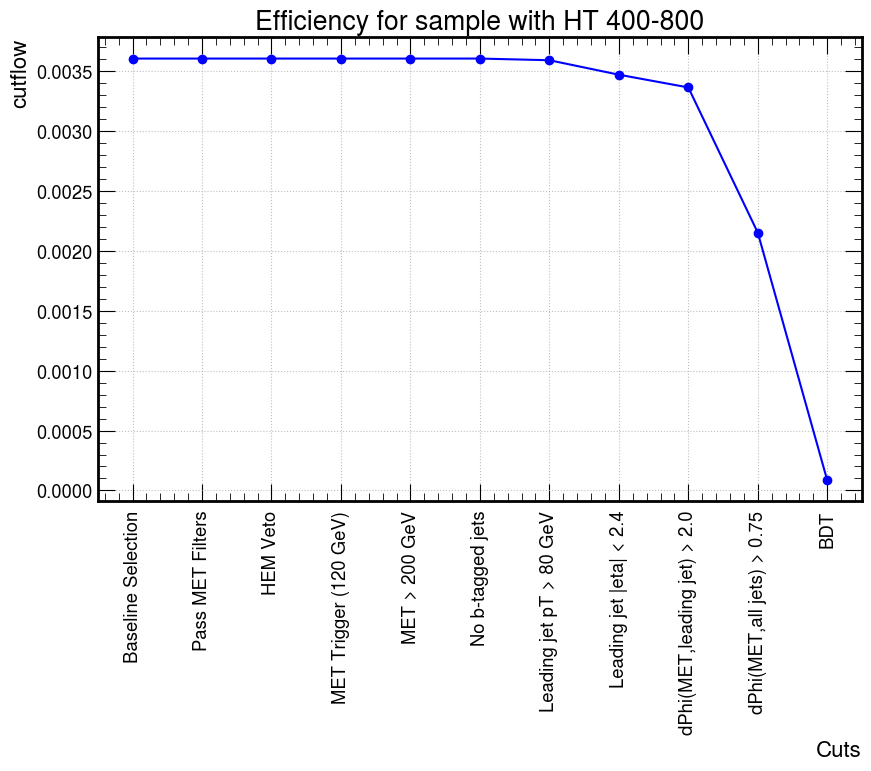

In [22]:
plt.figure(figsize=(9,8))
plt.title("Efficiency for sample with HT 400-800")

desc=list(cutNames.values())[1:]
print(desc)

cuts_eff = list(c_eff.keys())[1:]
values_eff = list(c_eff.values())[1:]

plt.plot(desc, values_eff, marker='o', linestyle='-', color='b', label='Cut flow')

#plt.yscale('log')

plt.xlabel('Cuts')
plt.ylabel('cutflow')
plt.xticks(rotation=90)  # Rotate cut labels for better readability
plt.grid(True)

plt.tight_layout()
plt.savefig("Efficiency_HT400to800.png") 
plt.show()

['Baseline Selection', 'Pass MET Filters', 'HEM Veto', 'MET Trigger (120 GeV)', 'MET > 200 GeV', 'No b-tagged jets', 'Leading jet pT > 80 GeV', 'Leading jet |eta| < 2.4', 'dPhi(MET,leading jet) > 2.0', 'dPhi(MET,all jets) > 0.75', 'BDT']


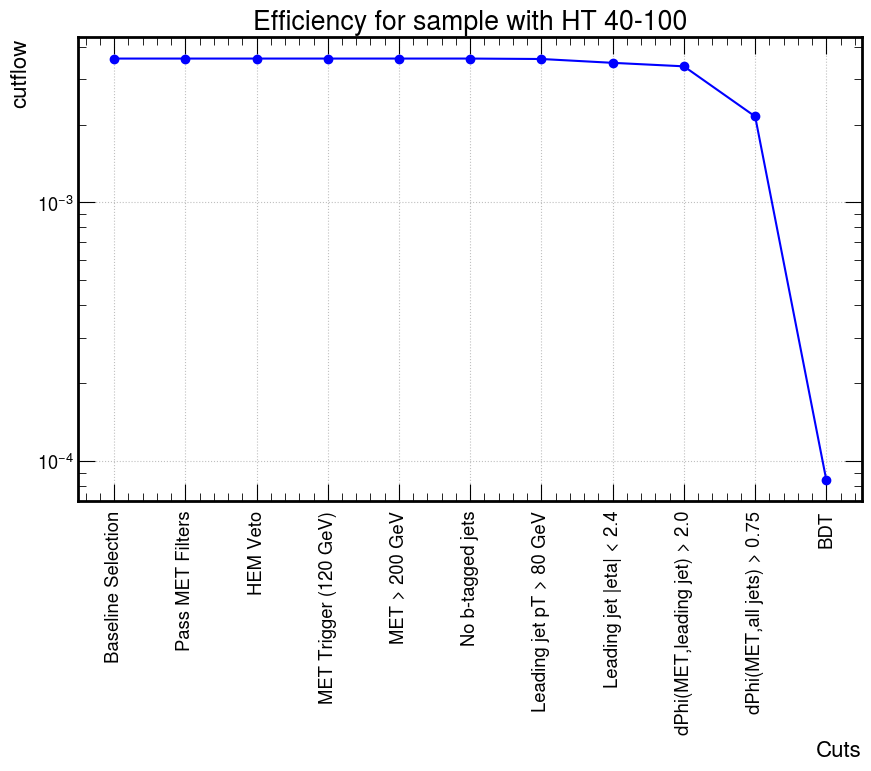

In [21]:
plt.figure(figsize=(9,8))
plt.title("Efficiency for sample with HT 40-100")

desc=list(cutNames.values())[1:]
print(desc)

cuts_eff = list(c_eff.keys())[1:]
values_eff = list(c_eff.values())[1:]

plt.plot(desc, values_eff, marker='o', linestyle='-', color='b', label='Cut flow')

plt.yscale('log')

plt.xlabel('Cuts')
plt.ylabel('cutflow')
plt.xticks(rotation=90)  # Rotate cut labels for better readability
plt.grid(True)

plt.tight_layout()
plt.savefig("Efficiency_log.png") 
plt.show()